In [3]:
import os
import numpy as np
import pandas as pd


experiment_dirs = {
    "Baseline": "/workspace/535505/ass3/save_model/atari_results/bs/",
    "Epsilon_deacy_0.99999": "/workspace/535505/ass3/save_model/atari_results/epsilon_deacy_0.99999/",
    "Epsilon_deacy_0.999999": "/workspace/535505/ass3/save_model/atari_results/epsilon_deacy_0.999999/",
    "Replay_5000": "/workspace/535505/ass3/save_model/atari_results/replay_5000",
    "Replay_20000": "/workspace/535505/ass3/save_model/atari_results/replay_20000",
    "Target_update_500": "/workspace/535505/ass3/save_model/atari_results/target_update_500",
    "Target_update_500": "/workspace/535505/ass3/save_model/atari_results/target_update_5000",
    "Train_setp_2": "/workspace/535505/ass3/save_model/atari_results/train_step_2",
    "Train_setp_5": "/workspace/535505/ass3/save_model/atari_results/train_step_5",
    
}

rows = []

for exp_name, exp_dir in experiment_dirs.items():
    summary_path = os.path.join(exp_dir, "training_summary.npy")

    if not os.path.exists(summary_path):
        print(f"[Warning] Missing file: {summary_path}")
        continue

    summary = np.load(summary_path, allow_pickle=True).item()

    rows.append({
        "Setting": exp_name,
        "Mean Eval Reward": summary.get("mean_eval_reward"),
        "Best Eval Reward": summary.get("best_eval_reward"),
        "Final Eval Reward": summary.get("final_eval_reward"),
        "Threshold Episode": summary.get("threshold_episode", None),
        "Threshold Env Step": summary.get("threshold_env_step", None),
        "Total Env Steps": summary.get("total_env_steps", None),
        "Total Updates": summary.get("total_updates", None),
    })

df = pd.DataFrame(rows)
print(df)

df.to_csv("/workspace/535505/ass3/pong_ablation_summary_table.csv", index=False)
print("[Info] Saved table to pong_summary_table.csv")

                  Setting  Mean Eval Reward  Best Eval Reward  \
0                Baseline            -16.00              -9.0   
1   Epsilon_deacy_0.99999            -16.64              -9.0   
2  Epsilon_deacy_0.999999            -17.16             -11.0   
3             Replay_5000            -16.96             -12.0   
4            Replay_20000            -17.00             -11.0   
5       Target_update_500            -16.60              -9.0   
6            Train_setp_2            -17.84             -15.0   
7            Train_setp_5            -19.48             -16.0   

   Final Eval Reward Threshold Episode Threshold Env Step  Total Env Steps  \
0              -18.0              None               None          3074267   
1               -9.0              None               None          3041679   
2              -18.0              None               None          3143262   
3              -15.0              None               None          3098603   
4              -15.0    

dict_keys(['train_episode', 'train_reward', 'eval_episode', 'eval_env_step', 'eval_reward'])


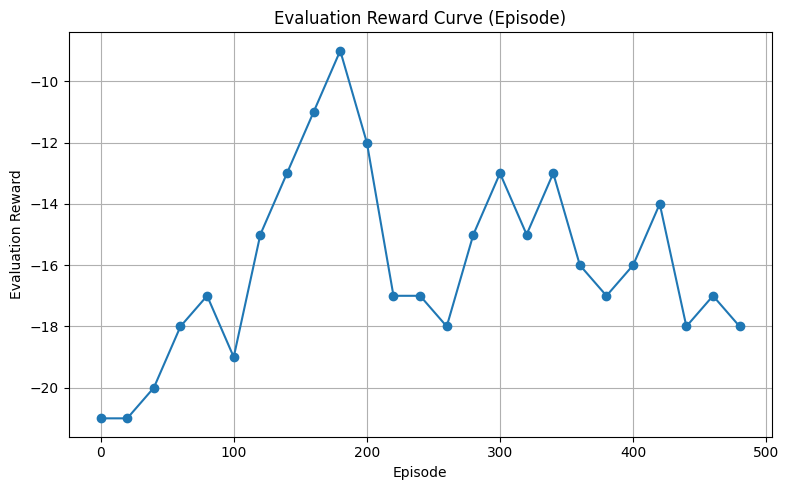

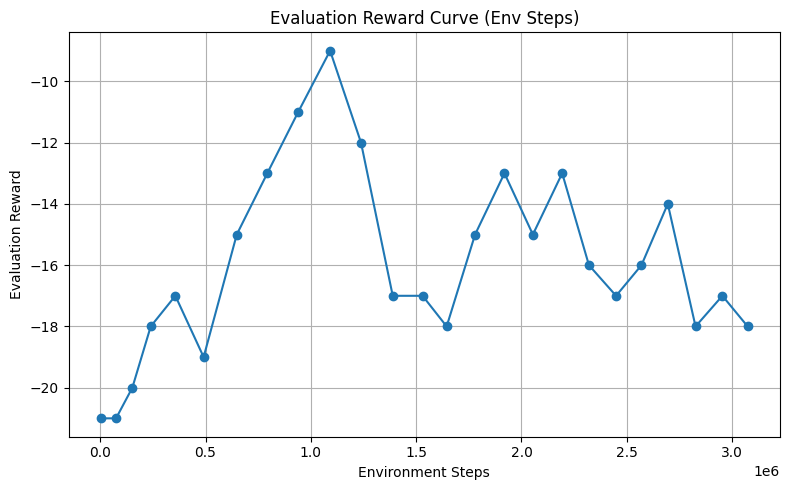

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt


save_dir = "/workspace/535505/ass3/"
f_name = "bs"
history_path = "/workspace/535505/ass3/save_model/atari_results/%s/training_history.npy"%f_name

history = np.load(history_path, allow_pickle=True).item()
print(history.keys())
eval_episode = history["eval_episode"]
eval_env_step = history["eval_env_step"]
eval_reward = history["eval_reward"]

# 用 episode 畫圖
plt.figure(figsize=(8, 5))
plt.plot(eval_episode, eval_reward, marker="o")
plt.xlabel("Episode")
plt.ylabel("Evaluation Reward")
plt.title("Evaluation Reward Curve (Episode)")
plt.grid(True)
plt.tight_layout()
plt.savefig(save_dir + "pong_eval_curve_by_episode_%s.png"%f_name)
plt.show()

# 用 env step 畫圖
plt.figure(figsize=(8, 5))
plt.plot(eval_env_step, eval_reward, marker="o")
plt.xlabel("Environment Steps")
plt.ylabel("Evaluation Reward")
plt.title("Evaluation Reward Curve (Env Steps)")
plt.grid(True)
plt.tight_layout()
plt.savefig(save_dir + "pong_eval_curve_by_envstep_%s.png"%f_name)
plt.show()

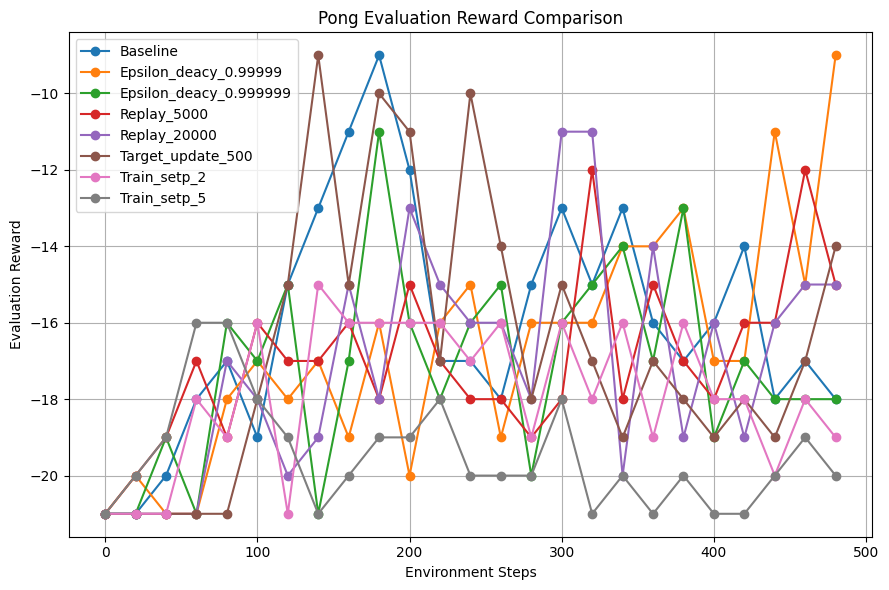

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

experiment_dirs = {
    "Baseline": "/workspace/535505/ass3/save_model/atari_results/bs/",
    "Epsilon_deacy_0.99999": "/workspace/535505/ass3/save_model/atari_results/epsilon_deacy_0.99999/",
    "Epsilon_deacy_0.999999": "/workspace/535505/ass3/save_model/atari_results/epsilon_deacy_0.999999/",
    "Replay_5000": "/workspace/535505/ass3/save_model/atari_results/replay_5000",
    "Replay_20000": "/workspace/535505/ass3/save_model/atari_results/replay_20000",
    "Target_update_500": "/workspace/535505/ass3/save_model/atari_results/target_update_500",
    "Target_update_500": "/workspace/535505/ass3/save_model/atari_results/target_update_5000",
    "Train_setp_2": "/workspace/535505/ass3/save_model/atari_results/train_step_2",
    "Train_setp_5": "/workspace/535505/ass3/save_model/atari_results/train_step_5",
}

save_dir = "/workspace/535505/ass3/"

plt.figure(figsize=(9, 6))

for exp_name, exp_dir in experiment_dirs.items():
    history_path = os.path.join(exp_dir, "training_history.npy")

    if not os.path.exists(history_path):
        print(f"[Warning] Missing file: {history_path}")
        continue

    history = np.load(history_path, allow_pickle=True).item()

    eval_episode = history["eval_episode"]
    eval_reward = history["eval_reward"]

    plt.plot(eval_episode, eval_reward, marker="o", label=exp_name)

plt.xlabel("Environment Steps")
plt.ylabel("Evaluation Reward")
plt.title("Pong Evaluation Reward Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(save_dir + "pong_ablation_eval_comparison.png")
plt.show()

In [ ]:
save_dir = "/workspace/535505/ass3/"
f_name = "bs"
history_path = "/workspace/535505/ass3/save_model/atari_results/%s/training_history.npy"%f_name
history = np.load(history_path, allow_pickle=True).item()

train_episode = history["train_episode"]
train_reward = history["eval_reward"]

plt.figure(figsize=(8, 5))
plt.plot(train_episode, train_reward)
plt.xlabel("Episode")
plt.ylabel("Training Reward")
plt.title("Training Reward Curve")
plt.grid(True)
plt.tight_layout()
plt.savefig(save_dir + "pong_train_reward_curve_%s.png"%f_name)
plt.show()

In [11]:
history_path = "/workspace/535505/ass3/save_model/atari_results/%s/training_summary.npy"%f_name
summary = np.load(history_path, allow_pickle=True).item()

keys = [
    "mean_eval_reward",
    "best_eval_reward",
    "final_eval_reward",
    "threshold_episode",
    "threshold_env_step",
    "total_env_steps",
    "total_updates",
]

print("Metric\tValue")
for k in keys:
    v = summary.get(k, None)
    if v is None and k in ["threshold_episode", "threshold_env_step"]:
        v = "Not reached"
    print(f"{k}\t{v}")

Metric	Value
mean_eval_reward	-16.0
best_eval_reward	-9.0
final_eval_reward	-18.0
threshold_episode	Not reached
threshold_env_step	Not reached
total_env_steps	3074267
total_updates	3064268


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1) Path settings
# =========================
f_name = "bs"
SAVE_DIR = "/workspace/535505/ass3/save_model/ppo_results/%s"%f_name
HIST_PATH = os.path.join(SAVE_DIR, "training_history.npy")
OUT_DIR = "/workspace/535505/ass3/"

# =========================
# 2) Load history
# =========================
history = np.load(HIST_PATH, allow_pickle=True).item()

# keys in ll_ppo.py:
# update, train_episode_reward, eval_update, eval_reward, policy_loss, value_loss, entropy
update = history.get("update", [])
train_episode_reward = history.get("train_episode_reward", [])
eval_update = history.get("eval_update", [])
eval_reward = history.get("eval_reward", [])
policy_loss = history.get("policy_loss", [])
value_loss = history.get("value_loss", [])
entropy = history.get("entropy", [])

print("Loaded history keys:", list(history.keys()))
print("Num updates:", len(update), "Num eval points:", len(eval_update))

# =========================
# 3) Helper: moving average (optional)
# =========================
def moving_average(x, w=10):
    x = np.array(x, dtype=np.float32)
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w) / w, mode="valid")

# =========================
# 4) Plot: Evaluation reward curve
# =========================
if len(eval_update) > 0 and len(eval_reward) > 0:
    plt.figure(figsize=(8, 5))
    plt.plot(eval_update, eval_reward, marker="o")
    plt.xlabel("Update")
    plt.ylabel("Evaluation Reward")
    plt.title("LunarLander PPO: Evaluation Reward Curve")
    plt.grid(True)
    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, "eval_reward_curve_%s.png"%f_name)
    plt.savefig(out_path)
    plt.close()
    print("[Saved]", out_path)

# =========================
# 5) Plot: Training reward trend
# =========================
if len(update) > 0 and len(train_episode_reward) > 0:
    plt.figure(figsize=(8, 5))
    plt.plot(update, train_episode_reward, label="Train Episode Reward (mean over rollout)")
    # optional smoothing
    ma = moving_average(train_episode_reward, w=10)
    if len(ma) > 0 and len(update) >= len(ma):
        plt.plot(update[len(update) - len(ma):], ma, label="Moving Avg (w=10)")
    plt.xlabel("Update")
    plt.ylabel("Reward")
    plt.title("LunarLander PPO: Training Reward Trend")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, "train_reward_trend_%s.png"%f_name)
    plt.savefig(out_path)
    plt.close()
    print("[Saved]", out_path)

# =========================
# 6) Plot: Loss curves
# =========================
if len(update) > 0 and (len(policy_loss) > 0 or len(value_loss) > 0):
    plt.figure(figsize=(8, 5))
    if len(policy_loss) > 0:
        plt.plot(update, policy_loss, label="Policy Loss")
    if len(value_loss) > 0:
        plt.plot(update, value_loss, label="Value Loss")
    plt.xlabel("Update")
    plt.ylabel("Loss")
    plt.title("LunarLander PPO: Loss Curves")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, "loss_curves_%s.png"%f_name)
    plt.savefig(out_path)
    plt.close()
    print("[Saved]", out_path)

# =========================
# 7) Plot: Entropy curve
# =========================
if len(update) > 0 and len(entropy) > 0:
    plt.figure(figsize=(8, 5))
    plt.plot(update, entropy)
    plt.xlabel("Update")
    plt.ylabel("Entropy")
    plt.title("LunarLander PPO: Entropy Curve")
    plt.grid(True)
    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, "entropy_curve_%s.png"%f_name)
    plt.savefig(out_path)
    plt.close()
    print("[Saved]", out_path)

print("\nDone. Plots saved to:", OUT_DIR)